In [1]:
import os
import sys
import random
import bentoml
import numpy as np
import pandas as pd
import pprint as pp
from pathlib import Path

# 현재 노트북이 있는 경로 기준으로 프로젝트 루트(recsys) 경로 계산
current_dir = (
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in globals()
    else os.getcwd()
)
project_root = os.path.abspath(os.path.join(current_dir, ".."))

# recsys 폴더를 sys.path에 추가
if project_root not in sys.path:
    sys.path.append(project_root)

from setup_env import setup_env

root_dir = setup_env()

from models.transformer.preprocess import SequenceGenerator
from utils.dataset.config import DatasetPath
from utils.dataset.plot import show_items
from models.transformer.model import Model
from utils.retriever.ann import build_index, search

device = "cpu"

[INFO] Font applied: NanumGothic


# Load Dataset

In [2]:
# 데이터셋 경로
dataset_dir = Path(root_dir).joinpath("data/dataset")
paths = DatasetPath(root_dir=dataset_dir, dataset_name="fashion")

df_item = pd.read_parquet(paths.item_metadata_path)
df_user_logs = pd.read_parquet(paths.user_logs_path)
df_user_logs.head()

,user_id,item_id,timestamp,action,age,gender,name,brand_name,price,discount_price,...,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,description
0,1,3583,2025-09-21 03:01:00,click,46,Unisex,Converse Unisex Red Basic Flip Flops,Converse,299.0,299.0,...,Red,Spring,2013,Casual,Footwear,Flip Flops,Flip Flops,<UNK>,<UNK>,<p>Red coloured flip flops<br />Thong style up...
1,1,9638,2025-09-21 03:02:00,click,46,Unisex,Puma Unisex MM II Blue Flip Flop,Puma,499.0,499.0,...,Blue,Spring,2012,Casual,Footwear,Flip Flops,Flip Flops,<UNK>,<UNK>,"<p style=""text-align: justify;"">Chill out in s..."
2,1,1679,2025-09-21 03:05:00,click,46,Unisex,Converse Unisex Black Flip Flops,Converse,299.0,299.0,...,Black,Spring,2013,Casual,Footwear,Flip Flops,Flip Flops,<UNK>,<UNK>,<p>Black flip flops<br />Thong style upper wit...
3,1,6133,2025-09-21 03:04:00,click,46,Unisex,Puma Unisex Wave Green Flip Flops,Puma,599.0,599.0,...,Green,Spring,2012,Casual,Footwear,Flip Flops,Flip Flops,<UNK>,<UNK>,<p>This absolutely stylish pair of Wave IND fl...
4,1,113,2025-09-21 03:17:00,click,46,Unisex,Puma Unisex Arizona Light Blue White Flip Flop,Puma,399.0,399.0,...,Blue,Spring,2012,Casual,Footwear,Flip Flops,Flip Flops,<UNK>,<UNK>,"<p style=""text-align: justify;"">A stroll on th..."


# Load Model

In [3]:
# 모델 저장 디렉토리 경로
seq_model_artifact = bentoml.models.get("transformer:latest")
reg_model_artifact = bentoml.models.get("regressor:latest")

seq_model_dir = Path(seq_model_artifact.path_of("artifact"))
reg_model_dir = Path(reg_model_artifact.path_of("artifact"))

# 모델 객체 초기화
model = Model(seq_model_dir=seq_model_dir, reg_model_dir=reg_model_dir)

/Users/hwangyungwan/miniforge3/envs/ds_p313/lib/python3.13/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


## Prediction Test

In [4]:
# 학습 데이터셋의 랜덤 유저를 추출하여 시퀀스 샘플 생성
user_id = random.choice(df_user_logs["user_id"].unique())
df_user_sample = df_user_logs[df_user_logs["user_id"] == user_id]
df_user_sample = df_user_sample.sort_values(by="user_id", ignore_index=True)

In [5]:
sequence_generator = SequenceGenerator(max_seq_len=model.seq_model_config["seq_len"])

feature_names = list(model.seq_model_config["feature_dims"].keys()) + ["item_id"]
target_names = list(model.seq_model_config["feature_dims"].keys())

df_seq_sample = sequence_generator.get_seq_dataframe(
    data=df_user_sample, feature_sequences=feature_names
)
df_seq_sample = df_seq_sample[df_seq_sample["seq_len"] == 5]
df_seq_sample

,user_id,user_rn,seq_len,mask,brand_name,gender,age_group,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,action,item_id,y_item_id
2,4372,3,5,"[0, 0, 0, 0, 0]","[Puma, Nike, Fastrack, Fastrack, CASIO]","[Men, Men, Women, Women, Women]","[Adults-Men, Adults-Men, Adults-Women, Adults-...","[White, Grey, Grey, Purple, White]","[Summer, Summer, Winter, Winter, Winter]","[2012, 2012, 2016, 2016, 2016]","[Sports, Sports, Casual, Casual, Casual]","[Footwear, Footwear, Accessories, Accessories,...","[Shoes, Shoes, Watches, Watches, Watches]","[Sports Shoes, Sports Shoes, Watches, Watches,...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, Casual]","[click, click, cart, click, wishlist]","[6470, 560, 5929, 4496, 8343]","[560, 5929, 4496, 8343, 2137]"
3,4372,5,5,"[0, 0, 0, 0, 0]","[Nike, Puma, Nike, Fastrack, Fastrack]","[Men, Men, Men, Women, Women]","[Adults-Men, Adults-Men, Adults-Men, Adults-Wo...","[Black, White, Grey, Grey, Purple]","[Summer, Summer, Summer, Winter, Winter]","[2012, 2012, 2012, 2016, 2016]","[Sports, Sports, Sports, Casual, Casual]","[Footwear, Footwear, Footwear, Accessories, Ac...","[Shoes, Shoes, Shoes, Watches, Watches]","[Sports Shoes, Sports Shoes, Sports Shoes, Wat...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[click, click, click, cart, click]","[112, 6470, 560, 5929, 4496]","[6470, 560, 5929, 4496, 8343]"
4,4372,6,5,"[0, 0, 0, 0, 0]","[Salomon, Nike, Puma, Nike, Fastrack]","[Men, Men, Men, Men, Women]","[Adults-Men, Adults-Men, Adults-Men, Adults-Me...","[Black, Black, White, Grey, Grey]","[Summer, Summer, Summer, Summer, Winter]","[2012, 2012, 2012, 2012, 2016]","[Sports, Sports, Sports, Sports, Casual]","[Footwear, Footwear, Footwear, Footwear, Acces...","[Shoes, Shoes, Shoes, Shoes, Watches]","[Sports Shoes, Sports Shoes, Sports Shoes, Spo...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[wishlist, click, click, click, cart]","[1136, 112, 6470, 560, 5929]","[112, 6470, 560, 5929, 4496]"
5,4372,7,5,"[0, 0, 0, 0, 0]","[Lucera, Lucera, Salomon, Nike, Puma]","[Women, Women, Men, Men, Men]","[Adults-Women, Adults-Women, Adults-Men, Adult...","[Silver, Gold, Black, Black, White]","[Summer, Summer, Summer, Summer, Summer]","[2013, 2013, 2012, 2012, 2012]","[Casual, Casual, Sports, Sports, Sports]","[Accessories, Accessories, Footwear, Footwear,...","[Jewellery, Jewellery, Shoes, Shoes, Shoes]","[Bangle, Bangle, Sports Shoes, Sports Shoes, S...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[wishlist, click, wishlist, click, click]","[465, 6687, 1136, 112, 6470]","[6687, 1136, 112, 6470, 560]"
6,4372,8,5,"[0, 0, 0, 0, 0]","[Lucera, Salomon, Nike, Puma, Nike]","[Women, Men, Men, Men, Men]","[Adults-Women, Adults-Men, Adults-Men, Adults-...","[Gold, Black, Black, White, Grey]","[Summer, Summer, Summer, Summer, Summer]","[2013, 2012, 2012, 2012, 2012]","[Casual, Sports, Sports, Sports, Sports]","[Accessories, Footwear, Footwear, Footwear, Fo...","[Jewellery, Shoes, Shoes, Shoes, Shoes]","[Bangle, Sports Shoes, Sports Shoes, Sports Sh...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[click, wishlist, click, click, click]","[6687, 1136, 112, 6470, 560]","[1136, 112, 6470, 560, 5929]"
8,4372,10,5,"[0, 0, 0, 0, 0]","[Citizen, ADIDAS, Puma, Nike, ADIDAS]","[Women, Men, Men, Men, Men]","[Adults-Women, Adults-Men, Adults-Men, Adults-...","[White, Black, Navy Blue, Black, Navy Blue]","[Winter, Summer, Summer, Summer, Summer]","[2016, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Accessories, Apparel, Apparel, Apparel, Apparel]","[Watches, Bottomwear, Bottomwear, Bottomwear, ...","[Watches, Track Pants, Track Pants, Track Pant...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, Casual, <UNK>, <UNK>, <UNK>]","[click, wishlist, click, click, wishlist]","[1765, 4264, 9518, 9744, 2878]","[4264, 9518, 9744, 2878, 6700]"


In [6]:
seq_sample = df_seq_sample.sample(1).to_dict(orient="records")[0]
seq_sample

{'user_id': 4372,
 'user_rn': 11,
 'seq_len': 5,
 'mask': [0, 0, 0, 0, 0],
 'brand_name': ['Nike', 'ADIDAS', 'ADIDAS', 'Puma', 'Fabindia'],
 'gender': ['Men', 'Men', 'Men', 'Men', 'Women'],
 'age_group': ['Adults-Men',
  'Adults-Men',
  'Adults-Men',
  'Adults-Men',
  'Adults-Women'],
 'base_color': ['Black', 'Navy Blue', 'Black', 'Black', 'Red'],
 'season': ['Summer', 'Summer', 'Summer', 'Summer', 'Summer'],
 'year': ['2012', '2012', '2012', '2012', '2012'],
 'usage': ['Casual', 'Casual', 'Casual', 'Casual', 'Ethnic'],
 'master_category': ['Apparel', 'Apparel', 'Apparel', 'Apparel', 'Apparel'],
 'sub_category': ['Bottomwear',
  'Bottomwear',
  'Bottomwear',
  'Bottomwear',
  'Bottomwear'],
 'article_type': ['Track Pants',
  'Track Pants',
  'Track Pants',
  'Track Pants',
  'Churidar'],
 'fit': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'occasion': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'action': ['click', 'wishlist', 'click', 'click', 'wishlist'],
 'item_id': [9744, 287

In [7]:
inputs = {}
for k in model.seq_model_config["feature_dims"].keys():
    inputs[k] = seq_sample[k]

pp.pprint(inputs)

{'action': ['click', 'wishlist', 'click', 'click', 'wishlist'],
 'age_group': ['Adults-Men',
               'Adults-Men',
               'Adults-Men',
               'Adults-Men',
               'Adults-Women'],
 'article_type': ['Track Pants',
                  'Track Pants',
                  'Track Pants',
                  'Track Pants',
                  'Churidar'],
 'base_color': ['Black', 'Navy Blue', 'Black', 'Black', 'Red'],
 'brand_name': ['Nike', 'ADIDAS', 'ADIDAS', 'Puma', 'Fabindia'],
 'fit': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'gender': ['Men', 'Men', 'Men', 'Men', 'Women'],
 'master_category': ['Apparel', 'Apparel', 'Apparel', 'Apparel', 'Apparel'],
 'occasion': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'season': ['Summer', 'Summer', 'Summer', 'Summer', 'Summer'],
 'sub_category': ['Bottomwear',
                  'Bottomwear',
                  'Bottomwear',
                  'Bottomwear',
                  'Bottomwear'],
 'usage': ['Casual', 'Casual',

In [8]:
# 예시 입력: user_id와 시퀀스
body = [{"user_id": 123, "inputs": inputs}]

# Model.predict 호출 -> Transformer + Projection 결과 생성
prediction = model.predict(body)[0]
# pp.pprint(prediction)
# 출력: {"outputs": feature별 예측 값, "seq_vector": [...], "item_vector": [...]}

# Recommendation

In [9]:
# 이미지 기반 아이템 벡터 로드
df_image_vectors = pd.read_parquet(paths.image_vectors_path)

# text_vectors: (num_items, dim) numpy float32 배열
image_vectors = np.array(df_image_vectors["image_vector"].tolist())
image_vectors = np.array(image_vectors).astype(np.float32)

# {item index: item_id} 매핑
# (`df_text_vectors.index는` row index이므로 range(0..N-1)로 반환함)
item_id_maps = dict(zip(df_image_vectors["item_id"].index, df_image_vectors["item_id"]))

In [10]:
# 아이템 벡터 ANN 인덱스 생성
item_index = build_index(image_vectors)

In [11]:
# projection 모델에서 뽑은 item vector
query_vector = np.array(prediction["item_vector"])

# 아이템 벡터 인덱스에 질의한 결과 획득
result = search(query_vector, item_index, top_k=30)

# 추천 아이템 Index (원본 ID가 아닌 별도의 인덱스)
item_indies = list(result.keys())

# 추천 아이템 ID 재매핑
recommendation = {}
for i in item_indies:
    # 원본 ID로 매핑
    item_id = item_id_maps[i]
    recommendation[item_id] = result[i]

recommendation

{6700: 0.3514823913574219,
 510: 0.3116956949234009,
 1605: 0.3088550567626953,
 7994: 0.29927611351013184,
 9942: 0.2925078272819519,
 9518: 0.28835391998291016,
 1774: 0.28759580850601196,
 6591: 0.28439080715179443,
 3313: 0.28410422801971436,
 2220: 0.281002402305603,
 4849: 0.2809962034225464,
 3000: 0.27893394231796265,
 5804: 0.2789258360862732,
 523: 0.2786720395088196,
 335: 0.27706027030944824,
 1121: 0.276486873626709,
 9731: 0.2720160484313965,
 9657: 0.2696852684020996,
 1054: 0.2687671184539795,
 5718: 0.2677558660507202,
 5178: 0.2673184275627136,
 6252: 0.26634681224823,
 3808: 0.26545900106430054,
 1134: 0.2644411325454712,
 6052: 0.26397740840911865,
 2592: 0.2625393271446228,
 4791: 0.26211118698120117,
 1426: 0.2619893550872803,
 2257: 0.2613821029663086,
 2878: 0.26051247119903564}

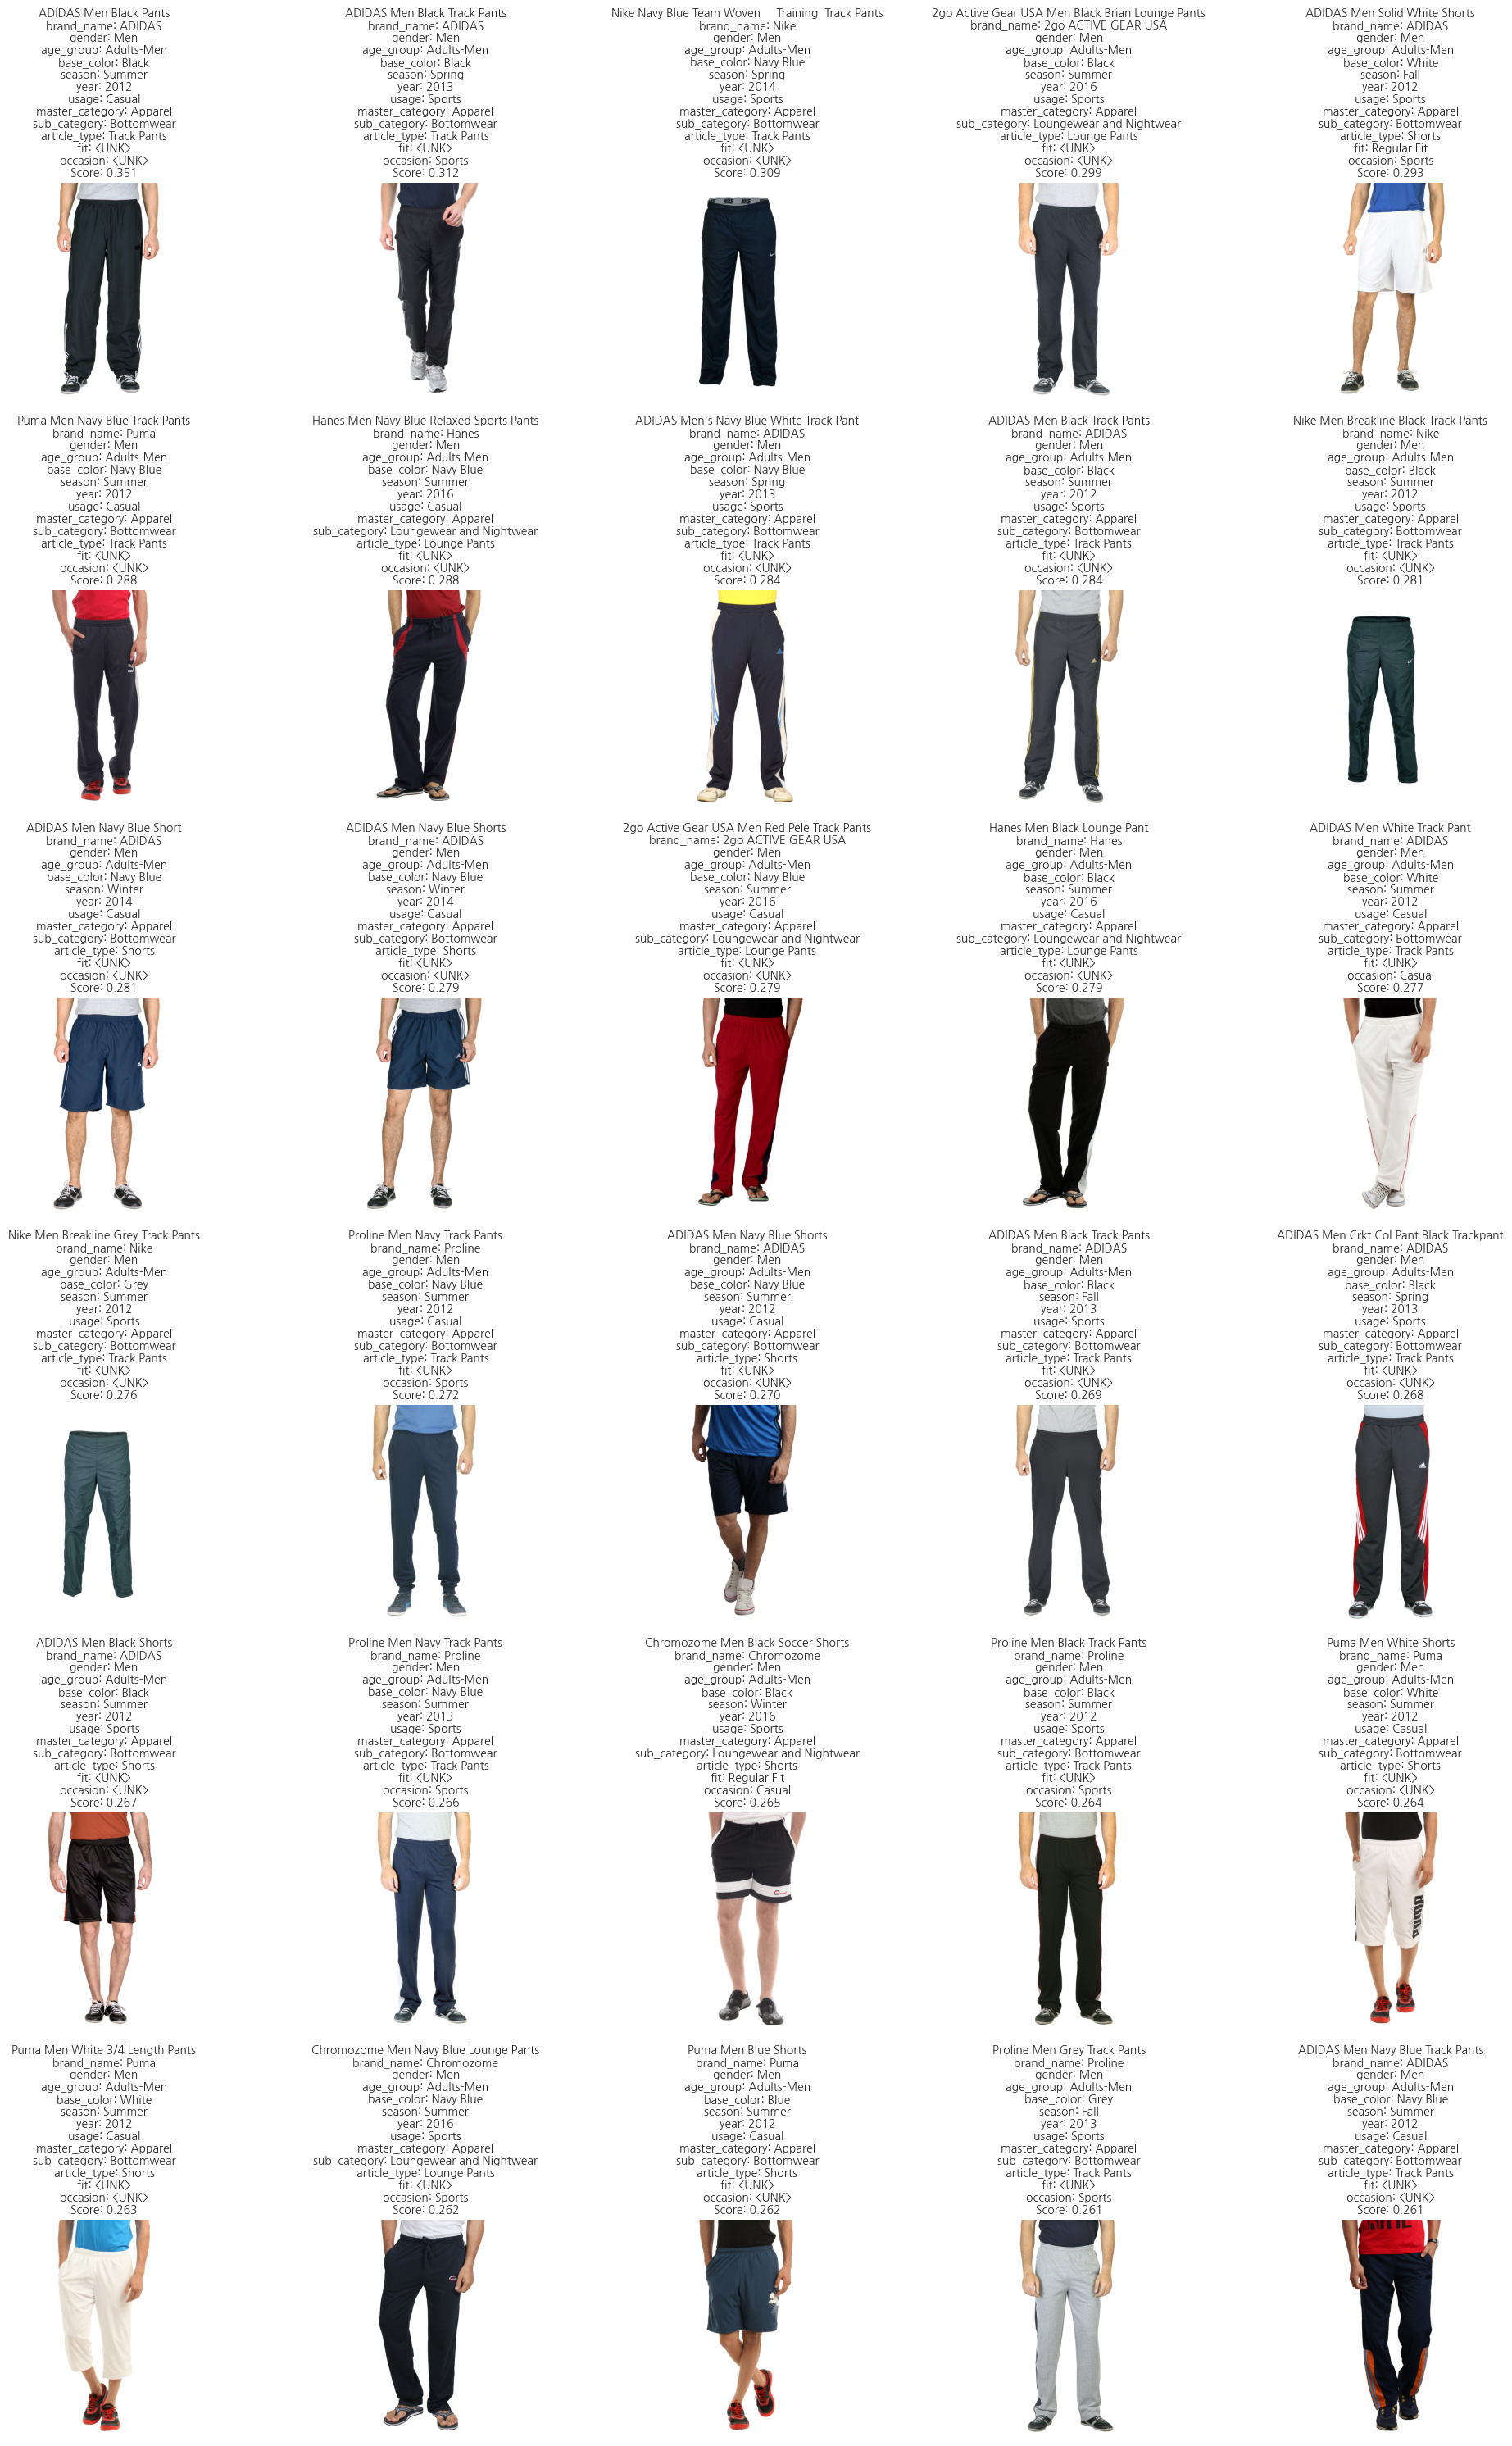

In [12]:
# 추천 아이템 후보군 상세 보기
show_items(
    item_ids=list(recommendation.keys()),
    df_item=df_item,
    attributes=tuple(model.seq_model_config["feature_dims"].keys()),
    scores=list(recommendation.values()),
    image_dir=paths.dataset_dir.joinpath("images"),
)